# Sistemas de Equações Lineares

Nesta aula, as equações são **algébricas** (sem derivadas): queremos achar números $x_1,x_2,\dots$ que satisfaçam várias equações lineares ao mesmo tempo. Isso vai aparecer em dois momentos ao resolver sistemas de EDOs: para achar autovetores e para ajustar condições iniciais.

## Duas retas no plano

Uma equação linear em duas incógnitas, como $x_1+x_2=3$, descreve uma **reta** no plano $x_1x_2$. Resolver um sistema de duas equações é encontrar os pontos que estão nas **duas** retas ao mesmo tempo. Só há três possibilidades:

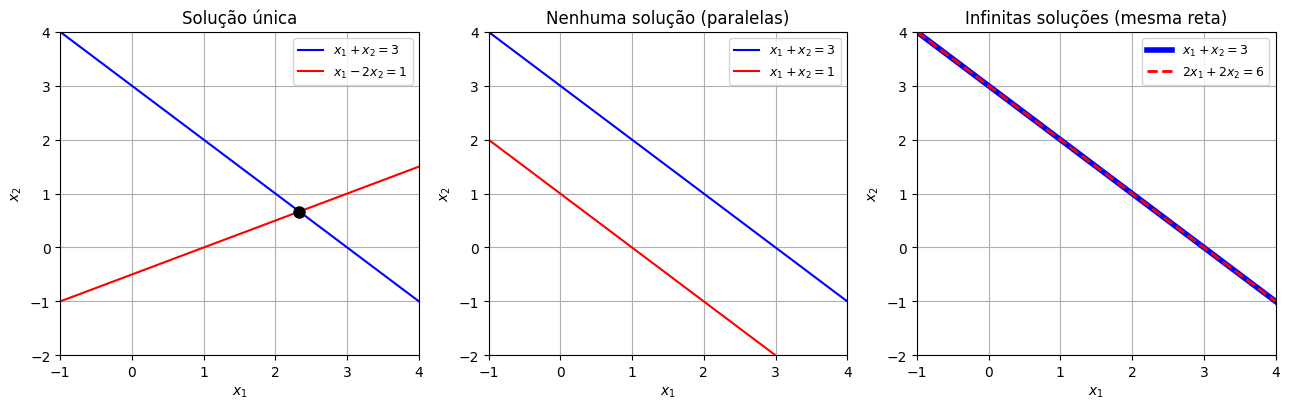

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x1 = np.linspace(-1, 4, 100)
fig, axs = plt.subplots(1, 3, figsize=(13, 4.2))

axs[0].plot(x1, 3 - x1, 'b', label='$x_1+x_2=3$')
axs[0].plot(x1, (x1 - 1)/2, 'r', label='$x_1-2x_2=1$')
axs[0].plot(7/3, 2/3, 'ko', markersize=8)
axs[0].set_title("Solução única")

axs[1].plot(x1, 3 - x1, 'b', label='$x_1+x_2=3$')
axs[1].plot(x1, 1 - x1, 'r', label='$x_1+x_2=1$')
axs[1].set_title("Nenhuma solução (paralelas)")

axs[2].plot(x1, 3 - x1, 'b', linewidth=4, label='$x_1+x_2=3$')
axs[2].plot(x1, 3 - x1, 'r--', linewidth=2, label='$2x_1+2x_2=6$')
axs[2].set_title("Infinitas soluções (mesma reta)")

for ax in axs:
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_xlim(-1, 4); ax.set_ylim(-2, 4)
    ax.legend(loc='upper right', fontsize=9); ax.grid(True)
plt.tight_layout()
plt.show()

* **Solução única:** as retas se cruzam num ponto. Em $x_1+x_2=3,\ x_1-2x_2=1$, subtraindo as equações, $3x_2=2$, então $x_2=\tfrac23$ e $x_1=\tfrac73$.
* **Nenhuma solução:** retas paralelas, como $x_1+x_2=3$ e $x_1+x_2=1$ — as equações são contraditórias.
* **Infinitas soluções:** as duas equações descrevem a mesma reta, como $x_1+x_2=3$ e $2x_1+2x_2=6$ — a segunda é só o dobro da primeira, e não traz informação nova.

Com três incógnitas a figura é a mesma ideia com planos no espaço, e as mesmas três possibilidades aparecem.

## Forma matricial e a inversa

Em forma matricial, um sistema de $n$ equações e $n$ incógnitas é $A\mathbf{x}=\mathbf{b}$. Os três casos acima são:

$$
\underbrace{\begin{pmatrix} 1 & 1\\ 1 & -2\end{pmatrix}}_{\det=-3}\mathbf{x} = \begin{pmatrix} 3\\ 1\end{pmatrix},
\qquad
\underbrace{\begin{pmatrix} 1 & 1\\ 1 & 1\end{pmatrix}}_{\det=0}\mathbf{x} = \begin{pmatrix} 3\\ 1\end{pmatrix},
\qquad
\underbrace{\begin{pmatrix} 1 & 1\\ 2 & 2\end{pmatrix}}_{\det=0}\mathbf{x} = \begin{pmatrix} 3\\ 6\end{pmatrix}.
$$

Repare: só no caso de solução única o determinante é diferente de zero. Isso vale em geral:

> * Se $\det A\neq0$, o sistema $A\mathbf{x}=\mathbf{b}$ tem **uma única solução**, $\mathbf{x}=A^{-1}\mathbf{b}$, para qualquer $\mathbf{b}$.
> * Se $\det A=0$, dependendo de $\mathbf{b}$, o sistema **não tem solução** ou tem **infinitas soluções**.

Geometricamente, $\det A=0$ significa que as retas (ou planos) têm a mesma inclinação: são paralelas ou coincidentes. Por exemplo, no primeiro sistema,

$$
\mathbf{x} = A^{-1}\mathbf{b} = \frac{1}{-3}\begin{pmatrix} -2 & -1\\ -1 & 1\end{pmatrix}\begin{pmatrix} 3\\ 1\end{pmatrix} = \begin{pmatrix} 7/3\\ 2/3\end{pmatrix}.
$$

## Sistemas homogêneos

Um sistema com $\mathbf{b}=\mathbf{0}$, ou seja, $A\mathbf{x}=\mathbf{0}$, é chamado **homogêneo**. Ele sempre tem pelo menos uma solução: a **trivial**, $\mathbf{x}=\mathbf{0}$. A pergunta é se existem outras. Pela regra acima:

> * Se $\det A\neq0$, a única solução de $A\mathbf{x}=\mathbf{0}$ é a trivial $\mathbf{x}=\mathbf{0}$.
> * Se $\det A=0$, existem **infinitas** soluções não nulas.

Esse segundo caso é exatamente o que vai acontecer quando procurarmos autovetores, então vale a pena ver com calma.

**Exemplo.** Resolva

$$
\begin{aligned}
x_1 - 2x_2 &= 0\\
-3x_1 + 6x_2 &= 0.
\end{aligned}
$$

Aqui $\det\begin{pmatrix} 1 & -2\\ -3 & 6\end{pmatrix} = 6-6=0$. De fato, a segunda equação é $-3$ vezes a primeira: na verdade só temos **uma** equação, $x_1=2x_2$. Uma das incógnitas fica livre: escolhendo $x_2=c$ (qualquer número), temos $x_1=2c$, e todas as soluções são

$$
\mathbf{x} = \begin{pmatrix} 2c\\ c\end{pmatrix} = c\begin{pmatrix} 2\\ 1\end{pmatrix}, \qquad c\in\mathbb{R}.
$$

São todos os múltiplos de um mesmo vetor: uma reta passando pela origem. Dizemos que a solução tem **um grau de liberdade** (uma constante livre).

Num sistema $3\times3$ singular podem sobrar um ou dois graus de liberdade. Por exemplo, em

$$
\begin{aligned}
x_1 + x_2 + x_3 &= 0\\
2x_1 + 2x_2 + 2x_3 &= 0\\
-x_1 - x_2 - x_3 &= 0,
\end{aligned}
$$

as três equações são a mesma. Escolhendo $x_1=c_1$ e $x_2=c_2$ livres, $x_3=-c_1-c_2$:

$$
\mathbf{x} = \begin{pmatrix} c_1\\ c_2\\ -c_1-c_2\end{pmatrix} = c_1\begin{pmatrix} 1\\ 0\\ -1\end{pmatrix} + c_2\begin{pmatrix} 0\\ 1\\ -1\end{pmatrix}.
$$

Dois graus de liberdade: as soluções formam um plano pela origem.

## Matriz aumentada e escalonamento

Quando o sistema é maior, o método sistemático é o de **eliminação de Gauss** (escalonamento). Escrevemos a **matriz aumentada** $(A\,|\,\mathbf{b})$ e usamos as mesmas operações elementares sobre as linhas da aula passada (trocar linhas, multiplicar uma linha por um número não nulo, somar a uma linha um múltiplo de outra) até obter uma matriz **triangular superior** (zeros abaixo da diagonal). Cada operação corresponde a uma manipulação legítima das equações, então o sistema não muda de solução.

**Exemplo 1 (solução única).** Resolva

$$
\begin{aligned}
x_1 - 2x_2 + 3x_3 &= 7\\
-x_1 + x_2 - 2x_3 &= -5\\
2x_1 - x_2 - x_3 &= 4.
\end{aligned}
$$

$$
\left(\begin{array}{ccc|c} 1 & -2 & 3 & 7\\ -1 & 1 & -2 & -5\\ 2 & -1 & -1 & 4\end{array}\right)
\xrightarrow[L_3\leftarrow L_3-2L_1]{L_2\leftarrow L_2+L_1}
\left(\begin{array}{ccc|c} 1 & -2 & 3 & 7\\ 0 & -1 & 1 & 2\\ 0 & 3 & -7 & -10\end{array}\right)
\xrightarrow{L_3\leftarrow L_3+3L_2}
\left(\begin{array}{ccc|c} 1 & -2 & 3 & 7\\ 0 & -1 & 1 & 2\\ 0 & 0 & -4 & -4\end{array}\right).
$$

Agora resolvemos **de baixo para cima** (substituição regressiva): da última linha, $-4x_3=-4$, então $x_3=1$; da segunda, $-x_2+x_3=2$, então $x_2=-1$; da primeira, $x_1=7+2x_2-3x_3=2$. Logo $\mathbf{x}=(2,-1,1)$.

**Exemplo 2 (matriz singular).** Troque o coeficiente de $x_3$ na terceira equação:

$$
\begin{aligned}
x_1 - 2x_2 + 3x_3 &= b_1\\
-x_1 + x_2 - 2x_3 &= b_2\\
2x_1 - x_2 + 3x_3 &= b_3.
\end{aligned}
$$

As mesmas operações levam a

$$
\left(\begin{array}{ccc|c} 1 & -2 & 3 & b_1\\ 0 & -1 & 1 & b_1+b_2\\ 0 & 0 & 0 & b_1+3b_2+b_3\end{array}\right).
$$

A última linha diz $0=b_1+3b_2+b_3$. Então:

* se $b_1+3b_2+b_3\neq0$, o sistema é contraditório e **não tem solução**;
* se $b_1+3b_2+b_3=0$, a última equação é sempre verdadeira, sobram duas equações para três incógnitas e há **infinitas soluções**.

Por exemplo, com $b_1=2,\ b_2=1,\ b_3=-5$ (que satisfazem a condição), sobra $x_1-2x_2+3x_3=2$ e $-x_2+x_3=3$. Escolhendo $x_3=\alpha$ livre: $x_2=\alpha-3$ e $x_1=2+2x_2-3x_3=-\alpha-4$, ou seja,

$$
\mathbf{x} = \alpha\begin{pmatrix} -1\\ 1\\ 1\end{pmatrix} + \begin{pmatrix} -4\\ -3\\ 0\end{pmatrix}.
$$

Repare na estrutura: uma **solução particular** $(-4,-3,0)$ mais a **solução geral do sistema homogêneo** $\alpha(-1,1,1)$ — a mesma estrutura $y=y_p+y_h$ das EDOs não homogêneas! O computador confirma os dois exemplos (o `sympy` também faz o escalonamento completo, com a função `rref`):

In [2]:
A1 = sp.Matrix([[1, -2, 3], [-1, 1, -2], [2, -1, -1]])
b1 = sp.Matrix([7, -5, 4])
print("Exemplo 1: det =", A1.det())
display(A1.LUsolve(b1))

A2 = sp.Matrix([[1, -2, 3], [-1, 1, -2], [2, -1, 3]])
print("Exemplo 2: det =", A2.det())
aumentada = A2.row_join(sp.Matrix([2, 1, -5]))
display(aumentada.rref()[0])     # forma escalonada reduzida
print("Soluções do homogêneo A x = 0:")
display(A2.nullspace())

Exemplo 1: det = 4


Matrix([
[ 2],
[-1],
[ 1]])

Exemplo 2: det = 0


Matrix([
[1, 0,  1, -4],
[0, 1, -1, -3],
[0, 0,  0,  0]])

Soluções do homogêneo A x = 0:


[Matrix([
 [-1],
 [ 1],
 [ 1]])]

## Dependência e independência linear

Na aula sobre o Wronskiano, falamos de funções "linearmente independentes". A ideia para vetores é a mesma: vetores $\mathbf{x}^{(1)},\dots,\mathbf{x}^{(k)}$ são **linearmente dependentes** se algum deles pode ser escrito como combinação dos outros, ou seja, se existem constantes $c_1,\dots,c_k$, **não todas nulas**, com

$$
c_1\mathbf{x}^{(1)} + c_2\mathbf{x}^{(2)} + \cdots + c_k\mathbf{x}^{(k)} = \mathbf{0}.
$$

Se a única forma de fazer isso é $c_1=\cdots=c_k=0$, eles são **linearmente independentes** (LI).

Para $n$ vetores com $n$ componentes, escrevemos os vetores como colunas de uma matriz $X$. A equação acima vira o sistema homogêneo $X\mathbf{c}=\mathbf{0}$ e, pela regra dos sistemas homogêneos:

> $n$ vetores com $n$ componentes são LI se, e somente se, $\det X\neq0$.

**Exemplo.** Os vetores $\begin{pmatrix} 1\\ 2\\ -1\end{pmatrix}$, $\begin{pmatrix} 2\\ 1\\ 3\end{pmatrix}$, $\begin{pmatrix} -4\\ 1\\ -11\end{pmatrix}$ são LI?

$$
\det\begin{pmatrix} 1 & 2 & -4\\ 2 & 1 & 1\\ -1 & 3 & -11\end{pmatrix} = 1(-11-3) - 2(-22+1) + (-4)(6+1) = -14+42-28 = 0.
$$

Não: são linearmente dependentes. Resolvendo $X\mathbf{c}=\mathbf{0}$ por escalonamento, encontra-se a relação $2\mathbf{x}^{(1)}-3\mathbf{x}^{(2)}-\mathbf{x}^{(3)}=\mathbf{0}$ (confira!): o terceiro vetor é combinação dos dois primeiros e não traz "direção nova".

Em dimensão $2$, dois vetores são dependentes exatamente quando são **múltiplos** um do outro (estão na mesma reta). É por isso que, ao procurar autovetores, vamos poder escolher qualquer múltiplo não nulo de um autovetor: todos representam a mesma direção.